In [59]:
from env_vars import CACHE_DIR
import ujson
import collections
import heapq
import copy
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats
from typing import Callable
from abc import ABC, abstractmethod

In [3]:
DATA_FILE = '/cmlscratch/snawathe/cmsc828g-proj/results_vllm/inference_qwen3-4b_math500_G4_B32768_chunk0.jsonl'

## Data Collection

Using vLLM, we run Qwen3.5 on all samples of Math500. For each question, we generate 32*8 total rollouts, using a batch size of 8, and record the generation time and response token length for each rollout. This gives us a dataset of rollouts lengths for every question.

In [4]:
raw_data = []
with open(DATA_FILE, 'r') as f:
	for line in f.readlines():
		raw_data.append(ujson.loads(line))

In [5]:
sample_to_rollouts_lengths = collections.defaultdict(list)
for sample in raw_data:
	sample_to_rollouts_lengths[sample['sample_idx']].extend(list(map(lambda x: len(x['token_ids']), sample['method_output']['outputs'])))

For each question, we now have samples of rollout lengths which we can draw from for simulation.

### Dataset Analysis

Rollouts tend to have long-tailed distributions. The paper "Scheduling LLM Inference with Uncertainty-Aware Output Length Predictions" argues that rollouts follow a Log-t distribution. Other distributions, such as Log-Gamma, may also work well.

To demonstrate this, we fit a Log-t distribution to the rollouts length dataset of one of the samples.

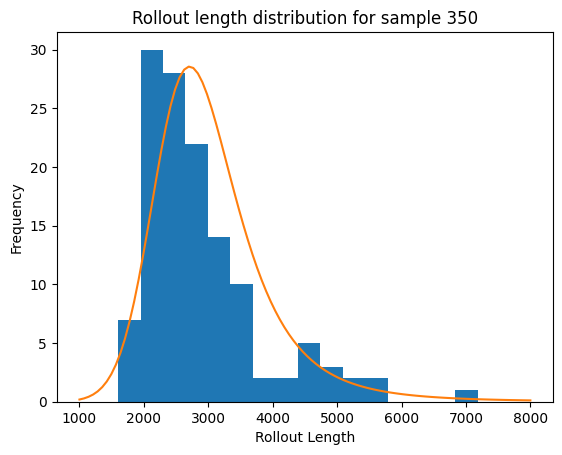

In [50]:
lst = np.array(sample_to_rollouts_lengths[350])
plt.hist(lst, bins=16)
x = np.linspace(1000, 8000, 100)
y = scipy.stats.t.pdf(np.log(x), *scipy.stats.t.fit(np.log(lst)))
plt.plot(x, 18*y)
plt.xlabel('Rollout Length')
plt.ylabel('Frequency')
plt.title('Rollout length distribution for sample 350')
plt.show()

Several rollouts are generated simultaneously, since this dataset uses a group size of $G=8$. We hypothesize that the total time taken for a rollout generation depends on the maximum length of a rollout within a group. To examine this, we plot this relationship.

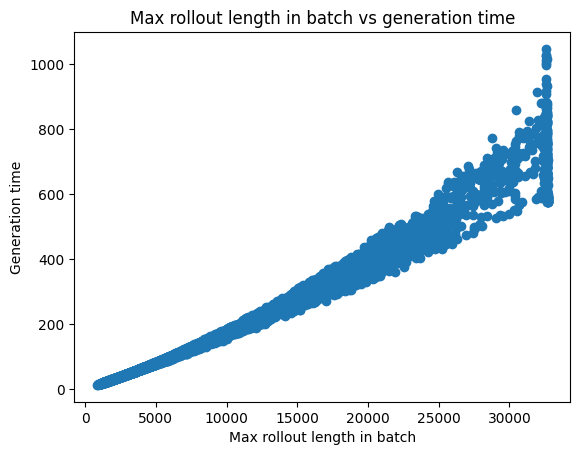

In [52]:
group_lens = []
for group_data in raw_data:
	group_lens.append(list(map(lambda x: len(x['token_ids']), group_data['method_output']['outputs'])))
gmax = list(map(max, group_lens))
gtimes = []
for group_data in raw_data:
	gtimes.append(group_data['generation_time'])

plt.scatter(gmax, gtimes)
plt.xlabel('Max rollout length in batch')
plt.ylabel('Generation time')
plt.title('Max rollout length in batch vs generation time')
plt.show()

### vLLM vs HuggingFace Transformers

vLLM is a highly optimized framework with two features that pose issues for our work:

1. Its paged attention uses CPU offloading when near memory capacity, which allows it to continue generation without OOM errors at the cost of speed
2. It has its own continuous batching algorithm: when given a large batch, it breaks it up to avoid OOM, and as early rollouts finish, it replaces them with new ones in a continuous manner to maximize resource usage.

As far as I can tell, these cannot be turned off. As these are both features of our desired work, we cannot use vLLM for our main experiments.

## Execution Method

We now describe our simulation execution setup, which mimics the inference portion of RL training.

Instead of actually performing inference on GPUs using our strategy, we can instead use the rollout lengths dataset previously collected. We can perform all the same batching and distribution steps as the real algorithm, but instead of actually performing inference to get the total time, we can instead use rollout lengths from the collected dataset and estimate the time using a simple mathematical model. This allows us to experiment with different scheduling strategies without costly inference.

Suppose our strategy tells us to perform inference on certain prompt simultaneously in a batch. From the rollout lengths dataset, we can get "simulated" rollout lengths for each prompt $\{l_i\}_{i=1}^B$. There are two things to consider: total time, and memory. Assuming no OOM errors, from the plot shown previously, we see that the total time $T$ for the batch is roughly proportional to the maximum rollout length; that is, $T \propto \max_i l_i$. Additionally, we conjecture that the time may also slightly depend on the batch size $B$ (a very large batch size may take slightly longer than a small batch size, for the same max rollout length). *TODO: collect data to quantify this accurately.* So, we model the time taken for a batch as follows:

In [53]:
def gen_time_model(lengths: list[int]) -> float:
	return 0.02 * max(lengths) * (1 + len(lengths) / 8)

Memory is another key concern; unlike vLLM, there is no automatic offloading with transformers; if an OOM error occurs, generation stops and all progress is lost. (Regular checkpointing could be used to save progress, but this likely adds significant overhead; it could be explored for critical / highly variable rollouts, though.) If an OOM error occurs, we will simply split the batch in half and regenerate all of the rollouts. The total time taken will be the time on the failed rollout, plus the time for each half-batch generation.

The total memory used for a batch is proportional to both the maximum rollout length and the batch size; that is $M \propto B \times \max_i l_i$..

In [54]:
def compute_batch_gen_time(lengths: list[int], mem_limit: int) -> float:
	t = gen_time_model(lengths)
	if max(lengths) * len(lengths) >= mem_limit:
		# if OOM: split into two batches and regenerate
		l1, l2 = lengths[:len(lengths) // 2], lengths[len(lengths) // 2:]
		t += compute_batch_gen_time(l1, mem_limit) + compute_batch_gen_time(l2, mem_limit)
		# print(f"OOM")
	return t

When a batching strategy is executed on a number of machines, we us a simply queueing system to assign batches to available machines. As soon as one machine finishes, it takes on the next batch in order, until all batches are completed.

In [55]:
def spread_batches_on_machines(batch_times: list[float], num_machines: int) -> float:
	machine_times = [0.0] * num_machines
	for t in batch_times:
		# assign to machine with least total time so far
		min_machine = min(range(num_machines), key=lambda i: machine_times[i])
		machine_times[min_machine] += t
	return max(machine_times)

For every "epoch" of training, we must perform $G$ inference rollouts on all prompts in the dataset. $G$ is the group size (typically 4 or 8 for small-scale RL setups; this group is used to compute advantages in GRPO, for example); in the experiments that follow, $G = 4$. $G$ is distinct from the batch size $B$, which is the number of rollouts being performed simultaneously on every inference. $B$ also need not be constant throughout the epoch: different prompt rollouts can be grouped together variably, as long as $G$ rollouts of each prompt are performed during the epoch.

On every epoch, a batching strategy will provde a list of batches to schedule, where each batch is a list of prompts (and each prompt appears exactly $G$ times total within the epoch). The following function uses the simulated rollout length data and the previous functions to simulate the performance of a provided strategy.

In [58]:
def simulate_strategy(strategy: 'BatchingStrategy', data: dict[int, list[int]], G: int, num_epochs: int, mem_limit: int, num_machines: int) -> list[float]:
	data = copy.deepcopy(data) # avoid mutating original data
	epoch_times: list[float] = []
	for _ in range(num_epochs):
		quota = {key: G for key in strategy.keys}
		batches = strategy.get_ordering()
		batch_times: list[float] = []
		for batch in batches:
			lengths = []
			run_length_data = []
			for key in batch:
				quota[key] -= 1
				l = data[key][0]
				lengths.append(l)
				run_length_data.append((key, l))
				data[key] = data[key][1:]
			batch_times.append(compute_batch_gen_time(lengths, mem_limit))
			strategy.ingest_run_data(run_length_data)
		assert all(q == 0 for q in quota.values())
		# print(f"{sum(batch_times)=}")
		epoch_times.append(spread_batches_on_machines(batch_times, num_machines=num_machines))
	return epoch_times

## Batching Methods

The base class `BatchingStrategy` contains two abstract methods. `ingest_run_data` is used to provide rollout length data to the strategy, to better inform its decisions. `get_ordering` is called at the start of each epoch, and must return the batches to be scheduled.

In [60]:
class BatchingStrategy(ABC):
	def __init__(self, keys: list[int], G: int):
		self.keys = keys
		self.G = G
	
	@abstractmethod
	def ingest_run_data(self, key_length_data: list[tuple[int, int]]):
		pass
	
	@abstractmethod
	def get_ordering(self) -> list[list[int]]:
		pass

For a simple baseline strategy: every prompt is in its own batch, and $G$ rollouts are performed simultaneously. (That is, we have $B = G$, and every prompt is in its own batch).

In [61]:
class BaselineStrategy(BatchingStrategy):
	def __init__(self, keys: list[int], G: int):
		super().__init__(keys, G)

	def ingest_run_data(self, key_length_data: list[tuple[int, int]]):
		pass
	
	def get_ordering(self) -> list[list[int]]:
		return [[x]*self.G for x in self.keys]

Next, we have an oracle strategy, representing the minimum time necessary for each batch, with foreknowledge of the length of each rollout. This strategy first sorts all prompt by their mean rollout length. Then, it greedily groups prompts together, such that the rollouts do not incur an OOM error.

In [63]:
class OracleStrategy(BatchingStrategy):
	def __init__(self, keys: list[int], G: int, data: dict[int, list[int]],):
		super().__init__(keys, G)
		self.data = copy.deepcopy(data)
		self.times: dict[int, list[int]] = {key: [] for key in keys}

	def ingest_run_data(self, key_length_data: list[tuple[int, int]]):
		for (k, l) in key_length_data:
			self.times[k].append(l)
	
	def get_ordering(self) -> list[list[int]]:
		means_and_keys = [(sum(self.times[k]) / len(self.times[k]) if len(self.times[k]) > 0 else 0, k) for k in self.keys]
		means_and_keys.sort()
		ans = []
		printable_ans = []
		while means_and_keys:
			k = [means_and_keys[0][1]]
			m = max(self.data[k[0]][:self.G])
			self.data[k[0]] = self.data[k[0]][self.G:]
			means_and_keys.pop(0)
			if m * self.G >= 4 * 28000:
				for _ in range(2): ans.append(k*(self.G//2)) # divide group if really long
				printable_ans.append(k + [None])
				continue
			while means_and_keys and max(m, max(self.data[means_and_keys[0][1]][:self.G])) * self.G * (1 + len(k)) < 4 * 28000:
				m = max(m, max(self.data[means_and_keys[0][1]][:self.G]))
				k.append(means_and_keys[0][1])
				self.data[k[-1]] = self.data[k[-1]][self.G:]
				means_and_keys.pop(0)
			# print(f"{(m, k)=}, ", end="")
			ans.append(k*self.G)
			printable_ans.append(k)
		# print(f"{printable_ans=}")
		return ans

Finally we have our own strategy, which uses collected data from past rollouts lengths predict rollout length distributions, and schedule accordingly.

For the first epoch, since no data is available, we fall back to the baseline strategy. Starting from the second epochs, we use `scipy.stats.f.fit` to model a Log-t distribution of the rollout length for every prompt. We sort the prompts in increasing order of mean rollout length. Then, we greedily group prompts in batches, while ensuring that the risk of OOM errors is small via the condition:
$$\mathbb{P}\left[\max_{i \in [B]} l_i > \frac{M^*}{B}\right] < \alpha$$
Here, $M^*$ is the total memory available for KV cache, $\alpha$ is a threshold (we choose $\alpha = 1\%$), and $B$ is the batch size (total number of prompts in the batch). (We are keeping all $G$ instances of a question within the same batch; that is, if we choose $P$ questions in the batch, then $B = G \times p$.) To calculate this probability, we use the following decomposition:
$$\mathbb{P}\left[\max_{i \in [B]} l_i > L\right] 1 - \prod_{i \in [B]} \left(1 - \mathbb{P}[l_i > L]\right)$$
Each probability on the right side can be computed using the CDF of the estimated distribution for the corresponding prompt.

Finally, we have one further optimization: for the hardest prompts, sometimes having even $G$ rollouts in a single batch is too long and leads to frequent OOM errors. If we predict this, then we split a single prompt into two rollouts (each with batch size $B = G / 2$).

In [66]:
class LogTStrategy(BatchingStrategy):
	def __init__(self, keys: list[int], G: int):
		super().__init__(keys, G)
		self.times: dict[int, list[int]] = {key: [] for key in keys}
		self.dist_params = {key: (0, 0, 0) for key in keys}

	def ingest_run_data(self, key_length_data: list[tuple[int, int]]):
		for (k, l) in key_length_data:
			self.times[k].append(l)
		for k in set(list(map(lambda t: t[0], key_length_data))):
			self.dist_params[k] = scipy.stats.t.fit(np.log(self.times[k]))

	def prob_exceed_limit(self, keys: list[int], limit: int) -> float:
		probs = []
		for k in keys:
			params = self.dist_params[k]
			prob = 1 - scipy.stats.t.cdf(np.log(limit), *params)
			probs.append(prob)
		return 1 - np.array([1-p for p in probs]).prod()
	
	def get_ordering(self) -> list[list[int]]:
		if all(len(self.times[k]) == 0 for k in self.keys):
			return [[x]*self.G for x in self.keys]
		means_and_keys = [(np.mean(self.times[k]) + 0.5 * np.std(self.times[k]), k) for k in self.keys]
		means_and_keys.sort()
		ans = []
		printable_ans = []
		while means_and_keys:
			m, k = means_and_keys[0][0], [means_and_keys[0][1]]
			means_and_keys.pop(0)
			if self.G * (m + 2 * np.std(self.times[k[0]])) >= 4 * 28000:
				for _ in range(2): ans.append(k*(self.G//2)) # divide group if really long
				printable_ans.append(k + [None])
				continue
			while means_and_keys and self.prob_exceed_limit((k + [means_and_keys[0][1]]) * self.G, (4*28000) // (self.G*(len(k)+1))) < 0.01:
				k.append(means_and_keys[0][1])
				means_and_keys.pop(0)
			ans.append(k * self.G)
			printable_ans.append(k)
		# print(f"{printable_ans=}")
		return ans

## Simulated Results

In [67]:
num_epochs = 16
G = 4
mem_limit = 28000 * 4
num_machines = 2

t_baseline = simulate_strategy(BaselineStrategy(keys=list(sample_to_rollouts_lengths.keys()), G=G), sample_to_rollouts_lengths, G=G, num_epochs=num_epochs, mem_limit=mem_limit, num_machines=num_machines)
t_oracle = simulate_strategy(OracleStrategy(keys=list(sample_to_rollouts_lengths.keys()), G=G, data=sample_to_rollouts_lengths), sample_to_rollouts_lengths, G=G, num_epochs=num_epochs, mem_limit=mem_limit, num_machines=num_machines)
t_logt = simulate_strategy(LogTStrategy(keys=list(sample_to_rollouts_lengths.keys()), G=G), sample_to_rollouts_lengths, G=G, num_epochs=num_epochs, mem_limit=mem_limit, num_machines=num_machines)

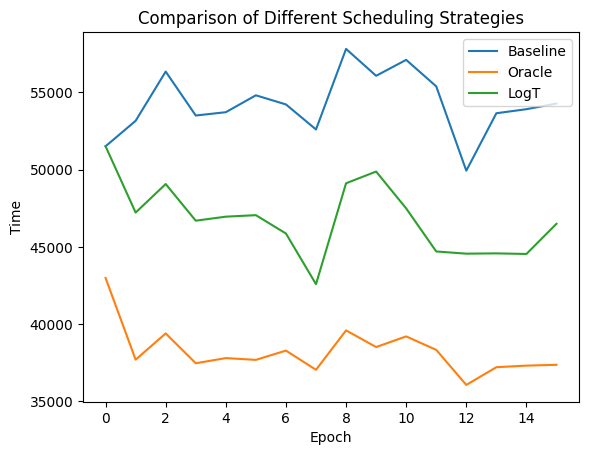

In [70]:
plt.plot(t_baseline, label='Baseline')
plt.plot(t_oracle, label='Oracle')
plt.plot(t_logt, label='LogT')
plt.xlabel('Epoch')
plt.ylabel('Time')
plt.title('Comparison of Different Scheduling Strategies')
plt.legend()
plt.show()